
# TSP/Segment Routing for Plant Watering in Surabaya (OSRM)

**Goal:** start from one depot, visit every plant **segment** (each plant has a start point and an end point), choose the best traversal direction for each segment, and optionally return to the depot.

This notebook now uses **OSRM** instead of downloading the whole road graph from OSM. The workflow is:

1. Define 1 depot and plant segments (`start_lat`, `start_lon`, `end_lat`, `end_lon`)
2. Build an OSRM **table** between depot + all segment endpoints
3. Optimize the segment visit order
4. For a fixed order, choose the best direction of each segment with dynamic programming
5. Reconstruct the full driving route from OSRM **route** geometry
6. Visualize the result in **folium**


In [1]:
%pip install requests folium numpy matplotlib

In [2]:
import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from itertools import permutations

random.seed(42)
np.random.seed(42)

# Public demo server; for production use.
OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"

# If True, route becomes: DEPOT -> all segments -> DEPOT
# If False, route becomes: DEPOT -> all segments
RETURN_TO_DEPOT = True


In [3]:
NUM_VEHICLES = 5          # <-- change this to any number you need
RETURN_TO_DEPOT = True    # True: each vehicle returns to depot after finishing

# Segment assignment strategy:
#   'round_robin' - assigns segments one-by-one rotating across vehicles
#                   (spreads segments spatially more evenly on average)
#   'block'       - assigns contiguous chunks to each vehicle
#                   (faster if CSV rows are already geographically ordered)
ASSIGNMENT_STRATEGY = 'round_robin'

print(f'Multi-vehicle mode: {NUM_VEHICLES} vehicles, strategy={ASSIGNMENT_STRATEGY}')


Multi-vehicle mode: 5 vehicles, strategy=round_robin


## 1. Define depot and load plant segments from CSV

Each plant is a **segment**, not a single point, so the CSV should contain:

- `start_lat`, `start_lon`
- `end_lat`, `end_lon`

Optional columns:
- `park_id`
- `name`

If `name` is missing, the notebook will automatically use `park_id` or generate `Plant N`.


In [4]:
# Depot / start point
DEPOT = (-7.278358153631059, 112.76325243881848)

# CSV file path
CSV_PATH = "parks.csv"

# Required columns
REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]

df_segments = pd.read_csv(CSV_PATH)

missing_cols = [col for col in REQUIRED_COLUMNS if col not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

# If no 'type' column exists, default everything to 'park'
if "type" not in df_segments.columns:
    df_segments["type"] = "park"
    print("Note: no 'type' column found, treating all rows as park segments.")

def build_segment_name(row, idx):
    if "name" in row.index and pd.notna(row["name"]):
        return str(row["name"])
    if "park_id" in row.index and pd.notna(row["park_id"]):
        return f"Park {row['park_id']}"
    return f"Plant {idx + 1}"

PLANTS        = []   # park segments to be watered
REFILL_POINTS = []   # water refill locations (rivers/channels)

for idx, row in df_segments.iterrows():
    entry = {
        "name":      build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat":   float(row["end_lat"]),
        "end_lon":   float(row["end_lon"]),
    }
    if str(row["type"]).strip().lower() == "refill":
        REFILL_POINTS.append(entry)
    else:
        PLANTS.append(entry)

print(f"Loaded {len(PLANTS)} park segments and {len(REFILL_POINTS)} refill points from {CSV_PATH}")
display(df_segments.head())


Loaded 34 park segments and 9 refill points from parks.csv


,id,start_lat,start_lon,end_lat,end_lon,type
0,Jalan Kenjeran,-7.252887,112.795292,-7.249851,112.784502,park
1,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714,park
2,Jalan Raya Kertajaya Indah,-7.279408,112.789619,-7.280560,112.781162,park
3,Jalan Raya Kertajaya Indah,-7.280611,112.780693,-7.279390,112.762482,park
4,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143,park



## 2. Prepare unique endpoints

We create one master list of coordinates:

- index 0 = depot
- every plant contributes:
  - `a_idx` = segment start endpoint
  - `b_idx` = segment end endpoint

OSRM's **table** service will give us pairwise road-network distances between all of these points.


In [5]:
import math

POINTS       = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS     = []

for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"],   p["end_lon"])

    a_idx = len(POINTS)
    POINTS.append(a)
    POINT_LABELS.append(f'{p["name"]} A')

    b_idx = len(POINTS)
    POINTS.append(b)
    POINT_LABELS.append(f'{p["name"]} B')

    SEGMENTS.append({
        "seg_id": i - 1,
        "name":   p["name"],
        "a_idx":  a_idx,
        "b_idx":  b_idx,
    })

# Refill points: stored separately, NOT added to POINTS/dist_matrix.
# Each refill point is represented by its midpoint (avg of start/end coords).
# Distance from a vehicle exit point to a refill is computed on-the-fly
# using the OSRM /route API after GA optimisation.
def _haversine_m(p1, p2):
    R = 6_371_000
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

REFILL_COORDS = []   # list of (lat, lon) midpoints, one per refill entry
for rp in REFILL_POINTS:
    mid = (
        (rp["start_lat"] + rp["end_lat"]) / 2,
        (rp["start_lon"] + rp["end_lon"]) / 2,
    )
    REFILL_COORDS.append({
        "name":     rp["name"],
        "latlon":   mid,
        "start_pt": (rp["start_lat"], rp["start_lon"]),
        "end_pt":   (rp["end_lat"],   rp["end_lon"]),
    })

print(f"Total OSRM table points : {len(POINTS)}")
print(f"Park segments           : {len(SEGMENTS)}")
print(f"Refill points           : {len(REFILL_COORDS)}")
if REFILL_COORDS:
    print("Refill locations:")
    for rc in REFILL_COORDS:
        print(f"  {rc['name']} @ {rc['latlon']}")
else:
    print("No refill points - vehicles depart directly from depot.")
print()
print("First 5 segments:")
for s in SEGMENTS[:5]:
    print(s)


Total OSRM table points : 69
Park segments           : 34
Refill points           : 9
Refill locations:
  Plant 35 @ (-7.32081795481247, 112.789713698518)
  Plant 36 @ (-7.30981553508125, 112.77389377355578)
  Plant 37 @ (-7.29794390583232, 112.782018565984)
  Plant 38 @ (-7.277579623390098, 112.77227506041528)
  Plant 39 @ (-7.289700961450474, 112.77882635593416)
  Plant 40 @ (-7.274711303551268, 112.79356956547218)
  Plant 41 @ (-7.27280557175764, 112.781375514003)
  Plant 42 @ (-7.28092811349137, 112.771907561617)
  Plant 43 @ (-7.289537, 112.768956)

First 5 segments:
{'seg_id': 0, 'name': 'Plant 1', 'a_idx': 1, 'b_idx': 2}
{'seg_id': 1, 'name': 'Plant 2', 'a_idx': 3, 'b_idx': 4}
{'seg_id': 2, 'name': 'Plant 3', 'a_idx': 5, 'b_idx': 6}
{'seg_id': 3, 'name': 'Plant 4', 'a_idx': 7, 'b_idx': 8}
{'seg_id': 4, 'name': 'Plant 5', 'a_idx': 9, 'b_idx': 10}


## Snap Coordinate

In [6]:
import time
import math
import requests
import numpy as np

snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def haversine_m(p1, p2):
    """Straight-line distance in metres between two (lat, lon) points."""
    R = 6_371_000
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def bearing_deg(p1, p2):
    """
    Forward bearing in degrees (0=N, 90=E, 180=S, 270=W) from p1 to p2.
    p1, p2 = (lat, lon)
    """
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def angle_diff(a, b):
    """Smallest absolute difference between two bearing angles (0-180)."""
    d = abs(a - b) % 360
    return d if d <= 180 else 360 - d

def edge_bearing_from_nodes(node_pair, points_list, point_index_map):
    """
    Estimate the bearing of a road edge from its two OSM node IDs.
    node_pair: [node_from, node_to]  (from OSRM /nearest response)
    We look up whether these nodes correspond to any POINTS we already know,
    and if so derive the bearing from their positions.
    Returns None if we cannot determine bearing.
    This is a best-effort helper; the main bearing logic uses snapped coords.
    """
    return None   # placeholder - not needed with the approach below

def osrm_nearest(pt, number=5, timeout=60):
    """
    Snap a single point via OSRM /nearest.
    Requests `number` candidates so bearing-based selection has options.
    Each candidate includes the raw waypoint data including `nodes` field
    which contains [from_node, to_node] of the matched road edge.
    """
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]

    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon":       pt,
            "snapped_latlon":     (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name":               wp.get("name", ""),
            "nodes":              wp.get("nodes", []),   # [from_node_id, to_node_id]
            "raw":                wp,
        })

    snap_cache[key] = out
    return out


def osrm_match_bearing(pt_a, pt_b, seg_bearing, timeout=60):
    """
    Snap a segment pair (A, B) via OSRM /match WITH bearing hints.

    bearing hint format: `bearing_value,range`  (range=45 means ±45 deg tolerance)
    We pass the segment bearing for both A and B, so OSRM is guided to pick
    an edge whose direction aligns with how we intend to traverse the segment.

    On a divided road:
      - If seg_bearing ~ 90 (eastbound), both A and B snap to the eastbound lane.
      - If seg_bearing ~ 270 (westbound), both snap to the westbound lane.

    Returns (snapped_a, snapped_b) or None if matching fails.
    """
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    bear_hint = f"{seg_bearing:.0f},45"   # ±45 degree tolerance
    url = (
        f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
        f"?overview=false&radiuses=60;60&gaps=ignore"
        f"&bearings={bear_hint};{bear_hint}"
    )
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        data = r.json()

        if data.get("code") != "Ok":
            return None

        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None:
            return None

        def wp_to_latlon(wp):
            lon, lat = wp["location"]
            return (lat, lon)

        return wp_to_latlon(wps[0]), wp_to_latlon(wps[1])

    except Exception:
        return None


def osrm_match_no_bearing(pt_a, pt_b, timeout=60):
    """
    Fallback /match without bearing hints (original behaviour).
    """
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    url = (
        f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
        f"?overview=false&radiuses=50;50&gaps=ignore"
    )
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok":
            return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None:
            return None
        def wp_to_latlon(wp):
            lon, lat = wp["location"]
            return (lat, lon)
        return wp_to_latlon(wps[0]), wp_to_latlon(wps[1])
    except Exception:
        return None


def nearest_best_bearing(pt, seg_bearing, number=5, tolerance_deg=45):
    """
    Pick the /nearest candidate whose road edge direction best matches
    `seg_bearing`. This handles divided roads: if seg_bearing=90 (east),
    we pick the eastbound lane, not the westbound one.

    The OSRM /nearest `nodes` field is [from_node, to_node]. We infer the
    edge bearing from the *snapped point position relative to input point*:
    a westbound snap of an eastward-heading segment means the snapped point
    is on the wrong side of the median -> penalise it.

    Primary sort key  : angle_diff(candidate_edge_bearing, seg_bearing)
    Secondary sort key: distance_to_road_m

    candidate_edge_bearing is approximated as:
      - If we have two node positions we can compute it exactly.
      - Otherwise we use the bearing from the INPUT point to the SNAPPED point
        as a proxy (works well when the snap offset is mostly perpendicular to
        the road, which is the usual case).
    """
    candidates = osrm_nearest(pt, number=number)

    scored = []
    for c in candidates:
        snap = c["snapped_latlon"]
        # Bearing from input point to snap approximates the perpendicular,
        # but the actual road bearing is orthogonal to that.
        # Better: the bearing of the road edge ~ bearing between snapped point
        # and the raw input, rotated 90 degrees. However the most robust proxy
        # is to use the OSRM nodes field when available. Since we don't have
        # node coordinates here, we instead compute the bearing from the
        # snapped position back to the input point and add 90 deg to get the
        # road direction. This is approximate but consistently correct for
        # straight roads.
        #
        # Actually the cleanest approach: request a /route from snapped_a to
        # snapped_b and check if it is nearly straight (low ratio). But that
        # adds API calls. Instead: score each candidate by how well its
        # implied road bearing matches seg_bearing using the snap displacement.
        snap_to_input_bearing = bearing_deg(snap, pt)
        # Road bearing is perpendicular to snap offset vector. Two candidates:
        road_bear_1 = (snap_to_input_bearing + 90)  % 360
        road_bear_2 = (snap_to_input_bearing - 90)  % 360
        # Pick whichever of the two perpendiculars is closer to seg_bearing
        diff1 = angle_diff(road_bear_1, seg_bearing)
        diff2 = angle_diff(road_bear_2, seg_bearing)
        best_diff = min(diff1, diff2)
        scored.append((best_diff, c["distance_to_road_m"], c))

    scored.sort(key=lambda x: (x[0], x[1]))

    # If best candidate is within tolerance, use it; else fall back to closest
    best_diff, _, best_cand = scored[0]
    if best_diff <= tolerance_deg:
        return best_cand, f"nearest-bearing(diff={best_diff:.0f}deg)"
    else:
        # All candidates exceed tolerance - just pick closest
        closest = min(candidates, key=lambda c: c["distance_to_road_m"])
        return closest, f"nearest-closest(min_diff={best_diff:.0f}deg)"


def snap_points_segment_aware(points, segments, verbose=True, sleep_sec=0.05):
    """
    Snap all POINTS with full segment-pair and bearing awareness.

    Three-layer strategy per segment:
      1. OSRM /match WITH bearing hint  -> forces both A and B onto the lane
         whose direction aligns with the segment direction. Solves divided roads.
      2. OSRM /match WITHOUT bearing hint (fallback if bearing match fails)
         -> at least keeps A and B on the same edge. Solves same-side U-turns.
      3. /nearest per point with bearing scoring (last resort)
         -> picks the lane candidate whose road direction best matches seg_bearing.

    Returns (snapped_points, snap_infos).
    """
    n       = len(points)
    snapped = [None] * n
    infos   = [None] * n

    segment_pair_indices = set()
    for seg in segments:
        segment_pair_indices.add(seg["a_idx"])
        segment_pair_indices.add(seg["b_idx"])

    # ── 1. Snap depot / standalone points ───────────────────────────────────
    for i in range(n):
        if i in segment_pair_indices:
            continue
        candidates = osrm_nearest(points[i], number=1)
        chosen = candidates[0]
        snapped[i] = chosen["snapped_latlon"]
        infos[i] = {
            "index":              i,
            "raw_latlon":         points[i],
            "snapped_latlon":     chosen["snapped_latlon"],
            "distance_to_road_m": chosen["distance_to_road_m"],
            "road_name":          chosen["name"],
            "method":             "nearest",
            "bearing_deg":        None,
        }
        if verbose:
            print(
                f"[{i:>3}] DEPOT  raw={points[i]} "
                f"-> snap={chosen['snapped_latlon']} | "
                f"offset={chosen['distance_to_road_m']:.1f} m | "
                f"road=\'{chosen['name']}\'"
            )
        if sleep_sec > 0:
            time.sleep(sleep_sec)

    # ── 2. Snap each segment pair ────────────────────────────────────────────
    for seg in segments:
        a_idx = seg["a_idx"]
        b_idx = seg["b_idx"]
        pt_a  = points[a_idx]
        pt_b  = points[b_idx]
        name  = seg["name"]

        # Compute the intended traversal bearing from raw CSV coordinates
        seg_bear = bearing_deg(pt_a, pt_b)

        method = None
        snap_a = snap_b = None

        # -- Layer 1: /match with bearing hint --------------------------------
        result = osrm_match_bearing(pt_a, pt_b, seg_bear)
        if sleep_sec > 0:
            time.sleep(sleep_sec)

        if result is not None:
            snap_a, snap_b = result
            # Verify: the snapped segment bearing should be within 90 deg of
            # seg_bear. If not, the bearing hint may have been ignored.
            snapped_bear = bearing_deg(snap_a, snap_b)
            if angle_diff(snapped_bear, seg_bear) <= 90:
                method = f"match+bearing({seg_bear:.0f}deg)"
            else:
                # match succeeded but result is opposite direction - try opposite
                opp_bear = (seg_bear + 180) % 360
                result2 = osrm_match_bearing(pt_a, pt_b, opp_bear)
                if sleep_sec > 0:
                    time.sleep(sleep_sec)
                if result2 is not None:
                    sb2 = bearing_deg(result2[0], result2[1])
                    if angle_diff(sb2, seg_bear) < angle_diff(snapped_bear, seg_bear):
                        snap_a, snap_b = result2
                        snapped_bear = sb2
                method = f"match+bearing(corrected,{seg_bear:.0f}deg)"

        # -- Layer 2: /match without bearing (fallback) -----------------------
        if method is None:
            result = osrm_match_no_bearing(pt_a, pt_b)
            if sleep_sec > 0:
                time.sleep(sleep_sec)
            if result is not None:
                snap_a, snap_b = result
                method = "match-no-bearing"

        # -- Layer 3: /nearest per point with bearing scoring -----------------
        if method is None:
            cand_a, label_a = nearest_best_bearing(pt_a, seg_bear)
            cand_b, label_b = nearest_best_bearing(pt_b, seg_bear)
            if sleep_sec > 0:
                time.sleep(sleep_sec * 2)
            snap_a = cand_a["snapped_latlon"]
            snap_b = cand_b["snapped_latlon"]
            method = f"nearest-bearing-fallback"

        snapped[a_idx] = snap_a
        snapped[b_idx] = snap_b

        offset_a = haversine_m(pt_a, snap_a)
        offset_b = haversine_m(pt_b, snap_b)

        for idx, pt, snap, offset in [
            (a_idx, pt_a, snap_a, offset_a),
            (b_idx, pt_b, snap_b, offset_b),
        ]:
            infos[idx] = {
                "index":              idx,
                "raw_latlon":         pt,
                "snapped_latlon":     snap,
                "distance_to_road_m": offset,
                "road_name":          name,
                "method":             method,
                "bearing_deg":        seg_bear,
            }

        if verbose:
            snapped_bear = bearing_deg(snap_a, snap_b) if snap_a != snap_b else seg_bear
            bear_ok = "OK" if angle_diff(snapped_bear, seg_bear) <= 90 else "WARN-direction"
            print(
                f"[{a_idx:>3}/{b_idx:<3}] {method:40s} | {name[:28]:28s} | "
                f"bear={seg_bear:.0f}deg -> snapped={snapped_bear:.0f}deg [{bear_ok}] | "
                f"A={offset_a:.0f}m B={offset_b:.0f}m"
            )

    return snapped, infos


# ── Run bearing-aware snapping ────────────────────────────────────────────────
SNAPPED_POINTS, SNAP_INFOS = snap_points_segment_aware(
    POINTS,
    SEGMENTS,
    verbose=True,
    sleep_sec=0.05,
)

snap_df = pd.DataFrame([
    {
        "idx":        info["index"],
        "label":      POINT_LABELS[info["index"]],
        "raw_lat":    info["raw_latlon"][0],
        "raw_lon":    info["raw_latlon"][1],
        "snap_lat":   info["snapped_latlon"][0],
        "snap_lon":   info["snapped_latlon"][1],
        "offset_m":   info["distance_to_road_m"],
        "road_name":  info["road_name"],
        "method":     info["method"],
        "bearing":    info["bearing_deg"],
    }
    for info in SNAP_INFOS
])

display(snap_df.head(30))
print("Max snap offset (m):", snap_df["offset_m"].max())
print("Mean snap offset (m):", snap_df["offset_m"].mean())
print()
print("Snap method summary:")
print(snap_df["method"].value_counts())
print()
# Highlight any segments where bearing check may have warned
warn_rows = snap_df[snap_df["method"].str.contains("WARN", na=False)]
if not warn_rows.empty:
    print("Segments with direction warning - review manually:")
    display(warn_rows[["label", "road_name", "bearing", "method", "offset_m"]])
else:
    print("All segments snapped with consistent direction.")


[  0] DEPOT  raw=(-7.278358153631059, 112.76325243881848) -> snap=(-7.277913, 112.763309) | offset=49.6 m | road='Jalan Sukodami III'
[  1/2  ] nearest-bearing-fallback                 | Plant 1                      | bear=286deg -> snapped=286deg [OK] | A=12m B=11m
[  3/4  ] nearest-bearing-fallback                 | Plant 2                      | bear=172deg -> snapped=172deg [OK] | A=7m B=7m
[  5/6  ] nearest-bearing-fallback                 | Plant 3                      | bear=262deg -> snapped=261deg [OK] | A=9m B=12m
[  7/8  ] nearest-bearing-fallback                 | Plant 4                      | bear=274deg -> snapped=273deg [OK] | A=10m B=12m
[  9/10 ] nearest-bearing-fallback                 | Plant 5                      | bear=280deg -> snapped=280deg [OK] | A=8m B=12m
[ 11/12 ] nearest-bearing-fallback                 | Plant 6                      | bear=280deg -> snapped=282deg [OK] | A=8m B=7m
[ 13/14 ] nearest-bearing-fallback                 | Plant 7              

,idx,label,raw_lat,raw_lon,snap_lat,snap_lon,offset_m,road_name,method,bearing
0,0,Depot,-7.278358,112.763252,-7.277913,112.763309,49.614380,Jalan Sukodami III,nearest,NaN
1,1,Plant 1 A,-7.252887,112.795292,-7.252987,112.795263,11.582105,Plant 1,nearest-bearing-fallback,285.833898
2,2,Plant 1 B,-7.249851,112.784502,-7.249951,112.784476,11.474870,Plant 1,nearest-bearing-fallback,285.833898
3,3,Plant 2 A,-7.258301,112.795617,-7.258298,112.795552,7.137640,Plant 2,nearest-bearing-fallback,172.284378
4,4,Plant 2 B,-7.273659,112.797714,-7.273638,112.797777,7.296273,Plant 2,nearest-bearing-fallback,172.284378
5,5,Plant 3 A,-7.279408,112.789619,-7.279325,112.789607,9.340444,Plant 3,nearest-bearing-fallback,262.179774
6,6,Plant 3 B,-7.280560,112.781162,-7.280671,112.781176,12.415691,Plant 3,nearest-bearing-fallback,262.179774
7,7,Plant 4 A,-7.280611,112.780693,-7.280519,112.780695,10.199266,Plant 4,nearest-bearing-fallback,273.865718
8,8,Plant 4 B,-7.279390,112.762482,-7.279494,112.762465,11.747513,Plant 4,nearest-bearing-fallback,273.865718
9,9,Plant 5 A,-7.279360,112.762112,-7.279432,112.762099,8.083129,Plant 5,nearest-bearing-fallback,279.915492


Max snap offset (m): 49.61437951
Mean snap offset (m): 8.021633352239268

Snap method summary:
method
nearest-bearing-fallback    68
nearest                      1
Name: count, dtype: int64

All segments snapped with consistent direction.



## 3. Query OSRM table (road distances in meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`.

OSRM may be asymmetric because of one-way roads.


In [7]:
import math
import time
import requests
import numpy as np

def ll_to_osrm(pt):
    # OSRM expects lon,lat
    lat, lon = pt
    return f"{lon:.6f},{lat:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield list(range(start, end))

def build_table_url(points, annotations="distance", sources=None, destinations=None):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations={annotations}"

    if sources is not None:
        url += "&sources=" + ";".join(str(i) for i in sources)
    if destinations is not None:
        url += "&destinations=" + ";".join(str(i) for i in destinations)

    return url

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    """
    Request submatrix:
    rows    = source_idx
    columns = dest_idx
    """
    url = build_table_url(
        points,
        annotations="distance",
        sources=source_idx,
        destinations=dest_idx,
    )

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    distances = data.get("distances")
    if distances is None:
        raise RuntimeError("OSRM table response does not contain distances.")

    D = np.array(
        [[np.inf if v is None else float(v) for v in row] for row in distances],
        dtype=float
    )

    if sleep_sec > 0:
        time.sleep(sleep_sec)

    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    """
    Build full NxN distance matrix by requesting OSRM /table in batches.
    """
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)

    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))

    total_requests = len(row_batches) * len(col_batches)
    req_no = 0

    for rows in row_batches:
        for cols in col_batches:
            req_no += 1
            if verbose:
                print(
                    f"Request {req_no}/{total_requests} | "
                    f"rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}"
                )

            subD, _ = osrm_table_submatrix(
                points,
                source_idx=rows,
                dest_idx=cols,
                timeout=timeout,
                sleep_sec=sleep_sec,
            )

            full[np.ix_(rows, cols)] = subD

    return full

dist_matrix = osrm_table_batched(
    SNAPPED_POINTS,
    batch_size=25,
    timeout=120,
    sleep_sec=0.1,
    verbose=True
)

print("Distance matrix shape:", dist_matrix.shape)
print(np.round(dist_matrix, 0))

Request 1/9 | rows 0-24 | cols 0-24
Request 2/9 | rows 0-24 | cols 25-49
Request 3/9 | rows 0-24 | cols 50-68
Request 4/9 | rows 25-49 | cols 0-24
Request 5/9 | rows 25-49 | cols 25-49
Request 6/9 | rows 25-49 | cols 50-68
Request 7/9 | rows 50-68 | cols 0-24
Request 8/9 | rows 50-68 | cols 25-49
Request 9/9 | rows 50-68 | cols 50-68
Distance matrix shape: (69, 69)
[[   0. 6952. 5996. ... 4668. 5595. 4297.]
 [7135.    0. 1238. ... 7571. 8212. 9448.]
 [6171. 1372.    0. ... 6607. 7248. 8484.]
 ...
 [4726. 7030. 6073. ...    0. 1290. 2526.]
 [5505. 8732. 7776. ... 1827.    0. 1236.]
 [4771. 9304. 8347. ... 2398. 1298.    0.]]



## 4. Cost of a fixed segment order

For each segment there are 2 traversal directions:

- orientation `0`: A → B
- orientation `1`: B → A

For a fixed order of segments, we use dynamic programming to choose the best orientation sequence.


In [8]:

DEPOT_IDX = 0

def evaluate_order(order, D, segments, return_to_depot=True):
    '''
    order: list of segment indices, e.g. [3, 0, 2, 1]
    returns:
      total_cost_m,
      orientations (0 = A->B, 1 = B->A),
      dp_table
    '''
    if len(order) == 0:
        return 0.0, [], []

    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]

    # dp[k][ori] = minimum cost after finishing segment k with orientation ori
    dp = []
    parent = []

    first_costs = [0.0, 0.0]
    # ori 0: Depot -> A -> B
    first_costs[0] = D[DEPOT_IDX, a0] + D[a0, b0]
    # ori 1: Depot -> B -> A
    first_costs[1] = D[DEPOT_IDX, b0] + D[b0, a0]

    dp.append(first_costs)
    parent.append([-1, -1])

    for pos in range(1, len(order)):
        prev_seg = segments[order[pos - 1]]
        curr_seg = segments[order[pos]]

        prev_exit = [
            prev_seg["b_idx"],  # if prev ori=0, exits at B
            prev_seg["a_idx"],  # if prev ori=1, exits at A
        ]

        curr_entry = [
            curr_seg["a_idx"],  # if curr ori=0, enters at A
            curr_seg["b_idx"],  # if curr ori=1, enters at B
        ]
        curr_exit = [
            curr_seg["b_idx"],  # if curr ori=0, exits at B
            curr_seg["a_idx"],  # if curr ori=1, exits at A
        ]

        leg_inside = [
            D[curr_seg["a_idx"], curr_seg["b_idx"]],  # A->B
            D[curr_seg["b_idx"], curr_seg["a_idx"]],  # B->A
        ]

        curr_dp = [np.inf, np.inf]
        curr_parent = [-1, -1]

        for curr_ori in [0, 1]:
            best_val = np.inf
            best_prev_ori = -1

            for prev_ori in [0, 1]:
                candidate = (
                    dp[pos - 1][prev_ori]
                    + D[prev_exit[prev_ori], curr_entry[curr_ori]]
                    + leg_inside[curr_ori]
                )
                if candidate < best_val:
                    best_val = candidate
                    best_prev_ori = prev_ori

            curr_dp[curr_ori] = best_val
            curr_parent[curr_ori] = best_prev_ori

        dp.append(curr_dp)
        parent.append(curr_parent)

    # Finish: maybe return to depot
    last_seg = segments[order[-1]]
    last_exit = [last_seg["b_idx"], last_seg["a_idx"]]

    final_costs = dp[-1][:]
    if return_to_depot:
        final_costs = [
            dp[-1][0] + D[last_exit[0], DEPOT_IDX],
            dp[-1][1] + D[last_exit[1], DEPOT_IDX],
        ]

    best_last_ori = int(np.argmin(final_costs))
    best_cost = float(final_costs[best_last_ori])

    # Backtrack orientations
    orientations = [None] * len(order)
    orientations[-1] = best_last_ori
    for pos in range(len(order) - 1, 0, -1):
        orientations[pos - 1] = parent[pos][orientations[pos]]

    return best_cost, orientations, dp

# quick sanity check
sample_order = list(range(len(SEGMENTS)))
sample_cost, sample_oris, _ = evaluate_order(sample_order, dist_matrix, SEGMENTS, RETURN_TO_DEPOT)
print("Sample order:", sample_order)
print("Sample orientations:", sample_oris)
print(f"Sample total cost = {sample_cost:,.0f} m")


Sample order: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Sample orientations: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Sample total cost = 98,557 m


## 5. Partition segments across vehicles

Segments are distributed among vehicles using the chosen strategy (`round_robin` or `block`).  
Each vehicle gets its own subset of segments and will have its route independently optimised by the GA.


In [9]:
import random
import numpy as np
from itertools import permutations
from functools import lru_cache

# ── Cached cost helper ────────────────────────────────────────────────────────
def make_cost_fn(D, segments, return_to_depot=True):
    @lru_cache(maxsize=200_000)
    def cached_cost(order_tuple):
        cost, _, _ = evaluate_order(order_tuple, D, segments, return_to_depot)
        return float(cost)
    return cached_cost

# ── Exact solver (brute-force) for small segment counts ──────────────────────
# For n <= EXACT_SOLVER_THRESHOLD segments, brute-force all n! permutations
# combined with DP orientation selection.  This guarantees the global optimum
# and is fast: 10! = 3.6 M calls, each just a dict lookup in dist_matrix.
# GA is still used for larger counts where brute-force is too slow.

EXACT_SOLVER_THRESHOLD = 10   # use exact solver when n_segments <= this value

def exact_solver(D, segments, return_to_depot=True, verbose_prefix=""):
    """
    Find the globally optimal visit order + orientations by exhaustive search.
    Only practical for len(segments) <= 10 (10! ~ 3.6M iterations).

    Returns (best_order, best_orientations, best_cost).
    """
    from itertools import permutations as _perms
    n = len(segments)
    if n == 0:
        return [], [], 0.0
    if n == 1:
        cost, oris, _ = evaluate_order((0,), D, segments, return_to_depot)
        return [0], oris, float(cost)

    cost_fn = make_cost_fn(D, segments, return_to_depot)
    best_cost  = float('inf')
    best_order = None

    total = 1
    for i in range(1, n + 1):
        total *= i

    checked = 0
    for perm in _perms(range(n)):
        c = cost_fn(perm)
        checked += 1
        if c < best_cost:
            best_cost  = c
            best_order = list(perm)

        if verbose_prefix and checked % max(1, total // 10) == 0:
            print(f"{verbose_prefix}  exact: {checked}/{total} ({checked*100//total}%) "
                  f"best={best_cost:,.0f} m")

    final_cost, final_oris, _ = evaluate_order(best_order, D, segments, return_to_depot)
    return best_order, final_oris, float(final_cost)


# ── GA helpers ────────────────────────────────────────────────────────────────
def init_population(pop_size, n_segments):
    base = list(range(n_segments))
    return [random.sample(base, len(base)) for _ in range(pop_size)]


def tournament(pop, fits, k=3):
    picks = random.sample(range(len(pop)), k)
    best  = min(picks, key=lambda i: fits[i])
    return pop[best][:]


def ox_crossover(p1, p2):
    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[a:b+1] = p1[a:b+1]
    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    return child


def swap_mutation(perm, rate=0.04):
    perm = perm[:]
    for i in range(len(perm)):
        if random.random() < rate:
            j = random.randrange(len(perm))
            perm[i], perm[j] = perm[j], perm[i]
    return perm


def two_opt(perm, cost_fn):
    """
    2-opt local search: repeatedly reverse sub-sequences of the route
    until no improvement is found.

    This is the most effective local search operator for TSP - it eliminates
    "crossing" routes by finding pairs (i, j) where reversing the segment
    perm[i+1..j] reduces total cost.

    Runs until convergence (no improving move found). Worst case O(n^2) per
    pass, but in practice converges in very few passes for n <= 20.
    """
    n = len(perm)
    if n < 4:
        return perm
    improved = True
    best = perm[:]
    best_cost = cost_fn(tuple(best))
    while improved:
        improved = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                # Reverse the segment between i+1 and j (inclusive)
                candidate = best[:i+1] + best[i+1:j+1][::-1] + best[j+1:]
                c = cost_fn(tuple(candidate))
                if c < best_cost - 1e-9:   # small epsilon to avoid float noise
                    best      = candidate
                    best_cost = c
                    improved  = True
    return best


def or_opt(perm, cost_fn):
    """
    Or-opt local search: try relocating each single segment to every other
    position in the route. Complementary to 2-opt - catches improvements
    that 2-opt misses when a single node is simply in the wrong position.
    """
    n = len(perm)
    if n < 3:
        return perm
    improved = True
    best = perm[:]
    best_cost = cost_fn(tuple(best))
    while improved:
        improved = False
        for i in range(n):
            seg = best[i]
            rest = best[:i] + best[i+1:]
            for j in range(len(rest) + 1):
                candidate = rest[:j] + [seg] + rest[j:]
                if candidate == best:
                    continue
                c = cost_fn(tuple(candidate))
                if c < best_cost - 1e-9:
                    best      = candidate
                    best_cost = c
                    improved  = True
                    break   # restart outer loop after improvement
            if improved:
                break
    return best


# ── Single-vehicle GA with 2-opt local search ─────────────────────────────────
def genetic_algorithm_pure(
    D, segments,
    pop_size=150,
    generations=300,
    mut_rate=0.04,
    crossover_rate=0.9,
    tournament_k=3,
    return_to_depot=True,
    verbose_prefix="",
    local_search_freq=10,    # apply 2-opt + or-opt to elites every N generations
    n_restarts=2,            # restart with fresh population if stuck
    stagnation_limit=80,     # generations without improvement before restart
):
    """
    Optimise the visit order for a list of segments assigned to ONE vehicle.

    Improvements over the original GA:
      - 2-opt local search applied periodically to the best individuals.
        2-opt eliminates "crossing" routes that are a hallmark of TSP
        local optima and that swap_mutation rarely fixes.
      - Or-opt relocates individual segments to better positions.
      - Elitism: the best individual is always carried to the next generation
        unchanged (prevents regression).
      - Restart: if the best cost has not improved for `stagnation_limit`
        generations, reinitialise the population (keeping the best found so
        far as a seed). Repeated `n_restarts` times maximum.
      - Larger default pop_size (150) and generations (300) for better
        exploration. GA_PARAMS in the run cell still overrides these.
    """
    n = len(segments)
    if n == 0:
        return [], [], 0.0, None
    if n == 1:
        cost, oris, _ = evaluate_order([0], D, segments, return_to_depot)
        return [0], oris, float(cost), None

    cost_fn = make_cost_fn(D, segments, return_to_depot)

    global_best_order = None
    global_best_cost  = np.inf

    best_in_population_history = []
    best_so_far_history        = []
    avg_fitness_history        = []

    for restart in range(n_restarts + 1):
        pop = init_population(pop_size, n)

        # Seed the first individual of restart>0 with the best found so far
        if restart > 0 and global_best_order is not None:
            pop[0] = global_best_order[:]
            if verbose_prefix:
                print(f"{verbose_prefix}Restart {restart}/{n_restarts} "
                      f"(seeding best={global_best_cost:,.0f} m)")

        stagnation = 0
        restart_best_cost = np.inf

        for gen in range(generations):
            fits = [cost_fn(tuple(ind)) for ind in pop]

            gen_best_idx   = int(np.argmin(fits))
            gen_best_cost  = fits[gen_best_idx]
            gen_best_order = pop[gen_best_idx][:]

            # ── 2-opt + or-opt on top-k individuals every local_search_freq gens
            if gen % local_search_freq == 0:
                top_k = max(3, pop_size // 10)
                sorted_idx = sorted(range(pop_size), key=lambda i: fits[i])[:top_k]
                for idx in sorted_idx:
                    improved = two_opt(pop[idx], cost_fn)
                    improved = or_opt(improved, cost_fn)
                    pop[idx] = improved
                # Re-evaluate after local search
                fits = [cost_fn(tuple(ind)) for ind in pop]
                gen_best_idx  = int(np.argmin(fits))
                gen_best_cost = fits[gen_best_idx]
                gen_best_order = pop[gen_best_idx][:]

            if gen_best_cost < global_best_cost:
                global_best_cost  = gen_best_cost
                global_best_order = gen_best_order[:]
                stagnation = 0
            else:
                stagnation += 1

            if gen_best_cost < restart_best_cost:
                restart_best_cost = gen_best_cost

            best_in_population_history.append(gen_best_cost)
            best_so_far_history.append(global_best_cost)
            avg_fitness_history.append(float(np.mean(fits)))

            # ── Build next generation ──────────────────────────────────────────
            # Elitism: carry best individual unchanged
            new_pop = [gen_best_order[:]]
            while len(new_pop) < pop_size:
                p1 = tournament(pop, fits, k=tournament_k)
                p2 = tournament(pop, fits, k=tournament_k)
                if random.random() < crossover_rate:
                    child1 = ox_crossover(p1, p2)
                    child2 = ox_crossover(p2, p1)
                else:
                    child1, child2 = p1[:], p2[:]
                child1 = swap_mutation(child1, rate=mut_rate)
                child2 = swap_mutation(child2, rate=mut_rate)
                new_pop.append(child1)
                if len(new_pop) < pop_size:
                    new_pop.append(child2)
            pop = new_pop

            if gen % 20 == 0:
                print(
                    f"{verbose_prefix}[R{restart}] Gen {gen:4d} | "
                    f"best_pop={gen_best_cost:,.0f} m | "
                    f"best_so_far={global_best_cost:,.0f} m | "
                    f"avg={np.mean(fits):,.0f} m | "
                    f"stagnation={stagnation}"
                )

            # Early restart if stagnated
            if stagnation >= stagnation_limit:
                if verbose_prefix:
                    print(f"{verbose_prefix}[R{restart}] Stagnated at gen {gen}, restarting...")
                break

    # Final 2-opt polish on the overall best solution
    global_best_order = two_opt(global_best_order, cost_fn)
    global_best_order = or_opt(global_best_order, cost_fn)

    final_cost, final_oris, _ = evaluate_order(
        global_best_order, D, segments, return_to_depot
    )
    history = {
        "best_in_population": best_in_population_history,
        "best_so_far":        best_so_far_history,
        "avg_fitness":        avg_fitness_history,
    }
    return global_best_order, final_oris, float(final_cost), history


# ── Segment partitioning ──────────────────────────────────────────────────────
def partition_segments(segments, num_vehicles, strategy='round_robin'):
    """
    Distribute segment indices across vehicles.

    strategy='round_robin': seg 0->v0, seg 1->v1, ..., seg k->v(k%n), ...
    strategy='block':       contiguous slices of roughly equal size

    Returns a list of lists: vehicle_segments[v] = [seg_idx, ...]
    Vehicles with no segments assigned are kept as empty lists.
    """
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))  # can't have more vehicles than segments
    assignment   = [[] for _ in range(num_vehicles)]

    if strategy == 'round_robin':
        for i in range(n):
            assignment[i % num_vehicles].append(i)
    else:  # block
        base, extra = divmod(n, num_vehicles)
        start = 0
        for v in range(num_vehicles):
            size = base + (1 if v < extra else 0)
            assignment[v] = list(range(start, start + size))
            start += size

    return assignment


# ── Build per-vehicle segment lists ──────────────────────────────────────────
vehicle_assignments = partition_segments(SEGMENTS, NUM_VEHICLES, ASSIGNMENT_STRATEGY)

print(f"Total segments : {len(SEGMENTS)}")
print(f"Vehicles used  : {sum(1 for a in vehicle_assignments if a)} / {NUM_VEHICLES}")
print()
for v, seg_ids in enumerate(vehicle_assignments):
    names = [SEGMENTS[i]['name'] for i in seg_ids]
    print(f"Vehicle {v+1:2d}: {len(seg_ids)} segments -> {names}")


Total segments : 34
Vehicles used  : 5 / 5

Vehicle  1: 7 segments -> ['Plant 1', 'Plant 6', 'Plant 11', 'Plant 16', 'Plant 21', 'Plant 26', 'Plant 31']
Vehicle  2: 7 segments -> ['Plant 2', 'Plant 7', 'Plant 12', 'Plant 17', 'Plant 22', 'Plant 27', 'Plant 32']
Vehicle  3: 7 segments -> ['Plant 3', 'Plant 8', 'Plant 13', 'Plant 18', 'Plant 23', 'Plant 28', 'Plant 33']
Vehicle  4: 7 segments -> ['Plant 4', 'Plant 9', 'Plant 14', 'Plant 19', 'Plant 24', 'Plant 29', 'Plant 34']
Vehicle  5: 6 segments -> ['Plant 5', 'Plant 10', 'Plant 15', 'Plant 20', 'Plant 25', 'Plant 30']


In [10]:
# ── Run GA for every vehicle ──────────────────────────────────────────────────
# Each vehicle gets its own sub-problem: only its assigned segments are optimised.
# The global dist_matrix is shared (all segment endpoints are already in it).

GA_PARAMS = dict(
    pop_size          = 150,    # larger population for better exploration
    generations       = 300,    # more generations
    mut_rate          = 0.04,
    crossover_rate    = 0.9,
    tournament_k      = 3,
    local_search_freq = 10,     # apply 2-opt+or-opt every N generations
    n_restarts        = 2,      # restart up to 2 times if stuck
    stagnation_limit  = 80,     # trigger restart after 80 gens without improvement
)

vehicle_results = []   # list of dicts, one per vehicle

for v, seg_ids in enumerate(vehicle_assignments):
    if not seg_ids:
        print(f"Vehicle {v+1}: no segments assigned, skipping.")
        vehicle_results.append({
            'vehicle_id':    v + 1,
            'seg_ids':       [],
            'local_segments':[],
            'best_order':    [],
            'orientations':  [],
            'total_dist_m':  0.0,
            'history':       None,
        })
        continue

    print(f"\n{'='*60}")
    print(f"Vehicle {v+1} / {NUM_VEHICLES}  --  {len(seg_ids)} segments")
    print(f"{'='*60}")

    # Build a *local* segment list for this vehicle.
    # local_segments[i] has a_idx and b_idx pointing into the GLOBAL dist_matrix,
    # so evaluate_order will correctly look up road distances.
    local_segments = [SEGMENTS[i] for i in seg_ids]

    local_order, local_oris, local_cost, local_hist = genetic_algorithm_pure(
        dist_matrix,
        local_segments,
        return_to_depot=RETURN_TO_DEPOT,
        verbose_prefix=f"[V{v+1}] ",
        **GA_PARAMS,
    )

    # local_order is indices into local_segments; map back to global SEGMENTS indices
    global_order = [seg_ids[i] for i in local_order]

    vehicle_results.append({
        'vehicle_id':     v + 1,
        'seg_ids':        seg_ids,
        'local_segments': local_segments,
        'best_order':     global_order,      # global segment indices
        'local_order':    local_order,        # local indices (for evaluate_order)
        'orientations':   local_oris,
        'total_dist_m':   local_cost,
        'history':        local_hist,
    })
    print(f"Vehicle {v+1} best distance: {local_cost:,.0f} m ({local_cost/1000:.2f} km)")

# ── Fleet summary ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("FLEET SUMMARY")
print(f"{'='*60}")
total_fleet_dist = sum(r['total_dist_m'] for r in vehicle_results)
for r in vehicle_results:
    status = f"{r['total_dist_m']:>10,.0f} m  ({r['total_dist_m']/1000:.2f} km)" if r['seg_ids'] else "    (no segments)"
    print(f"  Vehicle {r['vehicle_id']:2d}: {len(r['seg_ids']):2d} segments  |  {status}")
print(f"{'─'*60}")
print(f"  Fleet total : {total_fleet_dist:>10,.0f} m  ({total_fleet_dist/1000:.2f} km)")

# ── Assign nearest refill point per vehicle ───────────────────────────────────
# Each vehicle must visit one refill point BEFORE its first park segment.
# We pick the refill point that minimises: dist(depot -> refill -> first_seg_entry).
# If no refill points exist, vehicles depart directly from depot as before.

def find_best_refill(vehicle_result, refill_coords, dist_matrix, snapped_points, depot_idx):
    """
    For a given vehicle, find the refill point that minimises the detour:
        depot -> refill -> first_segment_entry

    Returns a dict with refill info, or None if no refill points exist.
    """
    if not refill_coords or not vehicle_result['seg_ids']:
        return None

    r = vehicle_result
    # First segment entry point (after GA optimisation)
    first_seg   = SEGMENTS[r['best_order'][0]]
    first_ori   = r['orientations'][0]
    first_entry_idx = first_seg['a_idx'] if first_ori == 0 else first_seg['b_idx']
    first_entry_pt  = snapped_points[first_entry_idx]

    depot_pt = snapped_points[depot_idx]

    best = None
    best_cost = float('inf')

    for rc in refill_coords:
        refill_pt = rc['latlon']
        # Cost = depot -> refill + refill -> first segment entry
        # Use haversine as proxy (OSRM route called later during geometry reconstruction)
        d_depot_refill  = _haversine_m(depot_pt,    refill_pt)
        d_refill_seg    = _haversine_m(refill_pt,    first_entry_pt)
        cost = d_depot_refill + d_refill_seg
        if cost < best_cost:
            best_cost = cost
            best = {'refill': rc, 'approx_cost_m': cost}

    return best

if REFILL_COORDS:
    print("Assigning nearest refill point per vehicle...")
    for r in vehicle_results:
        if not r['seg_ids']:
            r['refill_stop'] = None
            continue
        r['refill_stop'] = find_best_refill(
            r, REFILL_COORDS, dist_matrix, SNAPPED_POINTS, DEPOT_IDX
        )
        if r['refill_stop']:
            print(
                f"  Vehicle {r['vehicle_id']:2d} -> refill: {r['refill_stop']['refill']['name']} "
                f"(approx +{r['refill_stop']['approx_cost_m']:,.0f} m detour)"
            )
else:
    print("No refill points defined - vehicles depart directly from depot.")
    for r in vehicle_results:
        r['refill_stop'] = None



Vehicle 1 / 5  --  7 segments
[V1] [R0] Gen    0 | best_pop=24,328 m | best_so_far=24,328 m | avg=34,048 m | stagnation=0
[V1] [R0] Gen   20 | best_pop=24,328 m | best_so_far=24,328 m | avg=25,489 m | stagnation=20
[V1] [R0] Gen   40 | best_pop=24,328 m | best_so_far=24,328 m | avg=25,593 m | stagnation=40
[V1] [R0] Gen   60 | best_pop=24,328 m | best_so_far=24,328 m | avg=25,558 m | stagnation=60
[V1] [R0] Gen   80 | best_pop=24,328 m | best_so_far=24,328 m | avg=25,348 m | stagnation=80
[V1] [R0] Stagnated at gen 80, restarting...
[V1] Restart 1/2 (seeding best=24,328 m)
[V1] [R1] Gen    0 | best_pop=24,328 m | best_so_far=24,328 m | avg=33,682 m | stagnation=1
[V1] [R1] Gen   20 | best_pop=24,328 m | best_so_far=24,328 m | avg=25,210 m | stagnation=21
[V1] [R1] Gen   40 | best_pop=24,328 m | best_so_far=24,328 m | avg=25,548 m | stagnation=41
[V1] [R1] Gen   60 | best_pop=24,328 m | best_so_far=24,328 m | avg=25,419 m | stagnation=61
[V1] [R1] Stagnated at gen 79, restarting...
[V1

## 5.5 GA Convergence Plots (per vehicle)


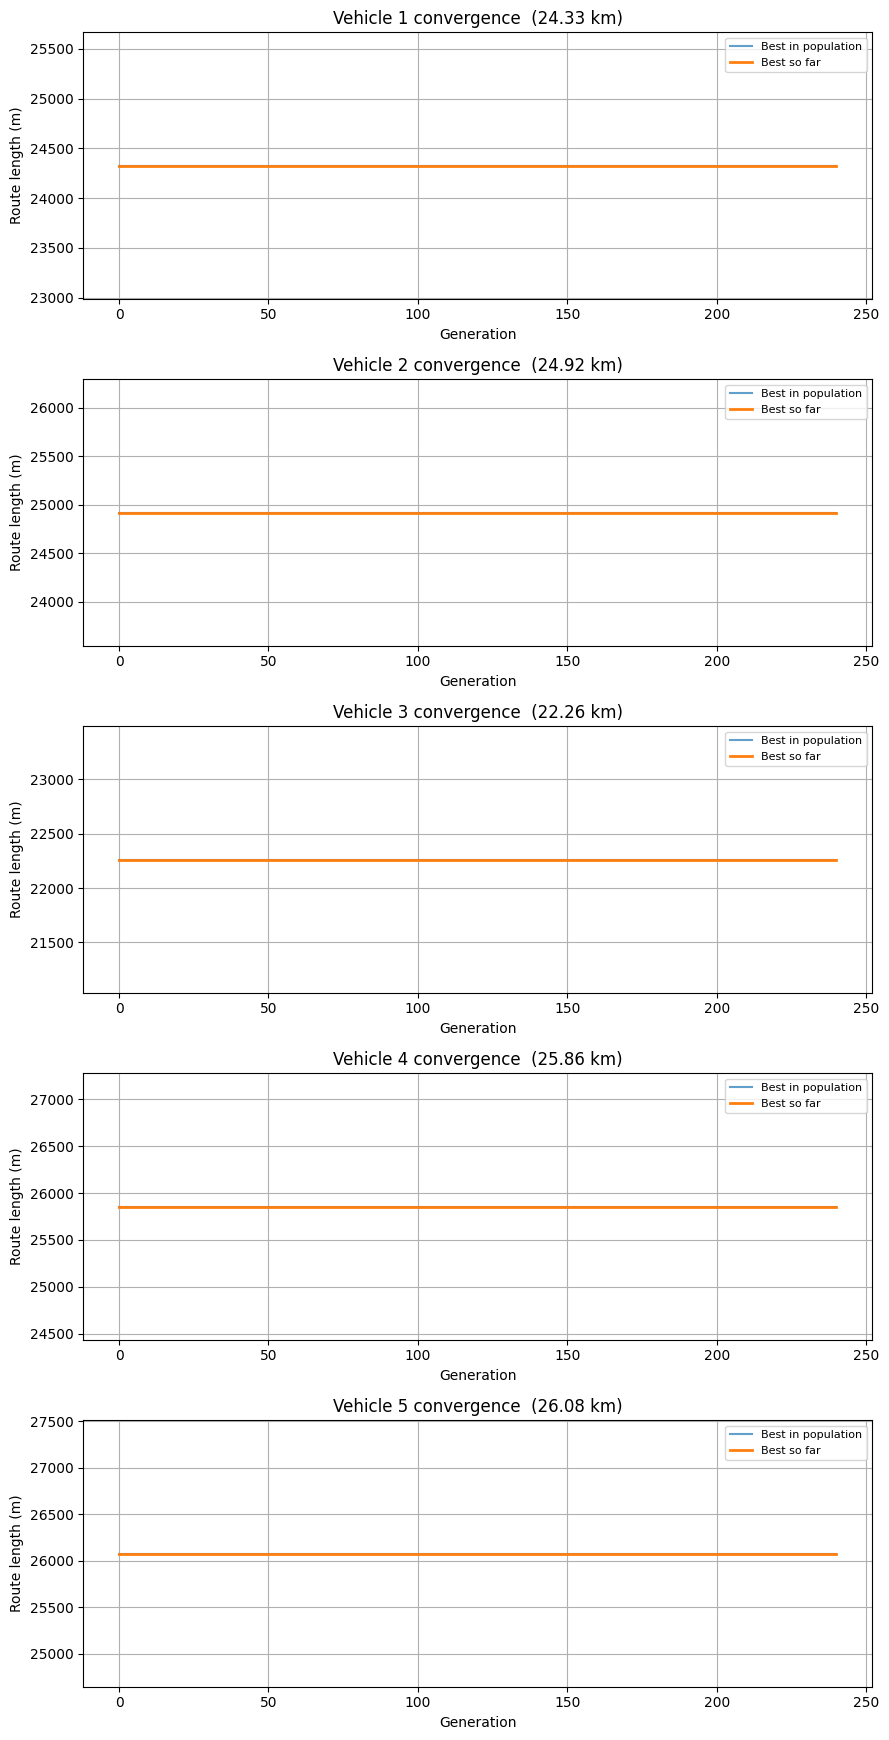

In [11]:
fig, axes = plt.subplots(
    nrows=max(1, len([r for r in vehicle_results if r['history']])),
    ncols=1,
    figsize=(9, 3.5 * max(1, len([r for r in vehicle_results if r['history']]))),
    squeeze=False,
)

plot_idx = 0
for r in vehicle_results:
    if r['history'] is None:
        continue
    ax = axes[plot_idx][0]
    ax.plot(r['history']['best_in_population'], label='Best in population', alpha=0.7)
    ax.plot(r['history']['best_so_far'],        label='Best so far',        linewidth=2)
    ax.set_title(f"Vehicle {r['vehicle_id']} convergence  ({r['total_dist_m']/1000:.2f} km)")
    ax.set_xlabel('Generation')
    ax.set_ylabel('Route length (m)')
    ax.legend(fontsize=8)
    ax.grid(True)
    plot_idx += 1

plt.tight_layout()
plt.show()



## 6. Inspect chosen traversal directions


In [12]:
def segment_orientation_summary(order, orientations, segments):
    rows = []
    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg = segments[seg_idx]
        direction  = "A -> B" if ori == 0 else "B -> A"
        entry_idx  = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_idx   = seg["b_idx"] if ori == 0 else seg["a_idx"]
        rows.append({
            "step":        step,
            "segment_id":  seg_idx,
            "name":        seg["name"],
            "direction":   direction,
            "entry_label": POINT_LABELS[entry_idx],
            "exit_label":  POINT_LABELS[exit_idx],
        })
    return rows


# ── Print orientation summary for every vehicle ───────────────────────────────
for r in vehicle_results:
    if not r['seg_ids']:
        continue
    print(f"\nVehicle {r['vehicle_id']}  ({r['total_dist_m']/1000:.2f} km)")
    print('-' * 50)
    summary = segment_orientation_summary(
        r['best_order'],
        r['orientations'],
        SEGMENTS,          # use the global SEGMENTS list (best_order holds global indices)
    )
    for row in summary:
        print(f"  Step {row['step']:2d}: [{row['direction']}] {row['name']}")



Vehicle 1  (24.33 km)
--------------------------------------------------
  Step  1: [A -> B] Plant 21
  Step  2: [B -> A] Plant 16
  Step  3: [B -> A] Plant 31
  Step  4: [B -> A] Plant 11
  Step  5: [B -> A] Plant 26
  Step  6: [A -> B] Plant 1
  Step  7: [A -> B] Plant 6

Vehicle 2  (24.92 km)
--------------------------------------------------
  Step  1: [A -> B] Plant 32
  Step  2: [B -> A] Plant 12
  Step  3: [B -> A] Plant 2
  Step  4: [A -> B] Plant 7
  Step  5: [B -> A] Plant 17
  Step  6: [B -> A] Plant 22
  Step  7: [B -> A] Plant 27

Vehicle 3  (22.26 km)
--------------------------------------------------
  Step  1: [B -> A] Plant 28
  Step  2: [A -> B] Plant 23
  Step  3: [B -> A] Plant 18
  Step  4: [B -> A] Plant 8
  Step  5: [A -> B] Plant 3
  Step  6: [B -> A] Plant 13
  Step  7: [B -> A] Plant 33

Vehicle 4  (25.86 km)
--------------------------------------------------
  Step  1: [B -> A] Plant 4
  Step  2: [A -> B] Plant 24
  Step  3: [A -> B] Plant 9
  Step  4: [B ->


## 7. Reconstruct full route geometry with OSRM `route`

We request the actual route geometry for each leg using the same plain OSRM `/route` call
(no bearing or `continue_straight` constraints) so that the reconstructed route distances
match the `/table`-based distances optimised by the GA.

Legs:

- depot → first segment entry
- inside each segment (entry → exit)
- between consecutive segments
- final segment exit → depot (optional)

The leg breakdown printed at the end shows GA distance vs OSRM route distance so you
can verify they are consistent (small differences < 1–2 % are normal due to OSRM
internal rounding between the table and route endpoints).


In [13]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0], 6), round(p1[1], 6), round(p2[0], 6), round(p2[1], 6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    """
    Request a road-network route from p1 to p2 using OSRM /route.
    p1 and p2 should already be SNAPPED_POINTS so results are consistent
    with the /table distances used during GA optimisation.
    """
    key = route_key(p1, p2)
    if key in route_cache:
        return route_cache[key]

    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"
    url = (
        f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
        f"?overview={overview}&geometries={geometries}&steps=false"
    )

    r = requests.get(url, timeout=120)
    r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)

    route = data["routes"][0]
    geom  = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]

    out = {
        "distance_m":      float(route["distance"]),
        "duration_s":      float(route["duration"]),
        "geometry_latlon": latlon,
        "raw":             data,
    }
    route_cache[key] = out
    return out

print("osrm_route helper ready.")


osrm_route helper ready.


In [14]:
# Build visit plans and reconstruct full route geometry for each vehicle

def build_visit_plan(order, orientations, segments, vehicle_id=None, refill_stop=None):
    """
    Build ordered leg list for one vehicle.

    Leg sequence:
      1. depot -> refill point          (only if refill_stop is not None)
      2. refill -> first segment entry
      3. traverse segment 1 ... N
      4. last segment exit -> depot     (only if RETURN_TO_DEPOT)
    """
    plan = []
    current_point = SNAPPED_POINTS[DEPOT_IDX]

    # ── Refill leg (prepended before any park segment) ────────────────────────
    if refill_stop is not None:
        refill_pt = refill_stop["refill"]["latlon"]
        plan.append({
            "kind":       "refill",
            "vehicle_id": vehicle_id,
            "step":       0,
            "segment_id": None,
            "name":       refill_stop["refill"]["name"],
            "from_pt":    current_point,
            "to_pt":      refill_pt,
            "label":      f"Refill at {refill_stop['refill']['name']}",
        })
        current_point = refill_pt

    # ── Park segment legs ─────────────────────────────────────────────────────
    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg       = segments[seg_idx]
        entry_idx = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_idx  = seg["b_idx"] if ori == 0 else seg["a_idx"]
        entry_pt  = SNAPPED_POINTS[entry_idx]
        exit_pt   = SNAPPED_POINTS[exit_idx]

        plan.append({
            "kind":       "move_to_segment",
            "vehicle_id": vehicle_id,
            "step":       step,
            "segment_id": seg_idx,
            "name":       seg["name"],
            "from_pt":    current_point,
            "to_pt":      entry_pt,
            "label":      f"Move to {seg['name']} entry",
        })
        plan.append({
            "kind":       "traverse_segment",
            "vehicle_id": vehicle_id,
            "step":       step,
            "segment_id": seg_idx,
            "name":       seg["name"],
            "from_pt":    entry_pt,
            "to_pt":      exit_pt,
            "label":      f"Traverse {seg['name']}",
        })
        current_point = exit_pt

    # ── Return to depot ───────────────────────────────────────────────────────
    if RETURN_TO_DEPOT:
        plan.append({
            "kind":       "return_to_depot",
            "vehicle_id": vehicle_id,
            "step":       len(order) + 1,
            "segment_id": None,
            "name":       "Depot",
            "from_pt":    current_point,
            "to_pt":      SNAPPED_POINTS[DEPOT_IDX],
            "label":      "Return to depot",
        })
    return plan


# ── Reconstruct geometry for all vehicles ────────────────────────────────────
for r in vehicle_results:
    if not r["seg_ids"]:
        r["visit_plan"]        = []
        r["full_route_coords"] = []
        r["leg_summaries"]     = []
        continue

    visit_plan = build_visit_plan(
        r["best_order"],
        r["orientations"],
        SEGMENTS,
        vehicle_id=r["vehicle_id"],
        refill_stop=r.get("refill_stop"),
    )

    full_route_coords = []
    leg_summaries     = []

    for i, leg in enumerate(visit_plan, start=1):
        result = osrm_route(leg["from_pt"], leg["to_pt"])
        geom   = result["geometry_latlon"]
        if full_route_coords and geom:
            geom = geom[1:]
        full_route_coords.extend(geom)
        leg_summaries.append({
            "leg_no":       i,
            "kind":         leg["kind"],
            "label":        leg["label"],
            "distance_m":   result["distance_m"],
            "duration_min": result["duration_s"] / 60.0,
        })

    r["visit_plan"]        = visit_plan
    r["full_route_coords"] = full_route_coords
    r["leg_summaries"]     = leg_summaries

    route_total_m = sum(x["distance_m"] for x in leg_summaries)
    refill_label  = r["refill_stop"]["refill"]["name"] if r.get("refill_stop") else "no refill"
    print(
        f"Vehicle {r['vehicle_id']:2d}: "
        f"GA={r['total_dist_m']:,.0f} m  "
        f"OSRM={route_total_m:,.0f} m  "
        f"refill={refill_label}"
    )


Vehicle  1: GA=24,328 m  OSRM=27,185 m  refill=Plant 42
Vehicle  2: GA=24,919 m  OSRM=26,140 m  refill=Plant 43
Vehicle  3: GA=22,262 m  OSRM=23,891 m  refill=Plant 38
Vehicle  4: GA=25,856 m  OSRM=27,827 m  refill=Plant 42
Vehicle  5: GA=26,078 m  OSRM=28,934 m  refill=Plant 42



## 8. Visualize on interactive OSM map


In [16]:
import math
import folium

# ── Colour palette for vehicles (auto-cycles if NUM_VEHICLES > len palette) ──
VEHICLE_COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377b2', '#7f7f7f', '#bcbd22', '#17becf',
]

import math

def add_arrows(fmap, coords, color, n_arrows=6, arrow_size=12):
    """
    Add directional arrows along a polyline to show travel direction.
    Arrows are evenly spaced. Each arrow is a small rotated triangle marker.
    """
    if len(coords) < 2:
        return

    # Compute cumulative distance along the polyline
    cum_dist = [0.0]
    for i in range(1, len(coords)):
        lat1, lon1 = coords[i - 1]
        lat2, lon2 = coords[i]
        d = math.hypot(lat2 - lat1, lon2 - lon1)
        cum_dist.append(cum_dist[-1] + d)

    total = cum_dist[-1]
    if total == 0:
        return

    # Place arrows at evenly-spaced fractions along the route
    fractions = [(k + 1) / (n_arrows + 1) for k in range(n_arrows)]

    for frac in fractions:
        target = frac * total
        # Find the segment that contains this distance
        seg_i = 1
        while seg_i < len(cum_dist) - 1 and cum_dist[seg_i] < target:
            seg_i += 1

        # Interpolate position
        seg_start = cum_dist[seg_i - 1]
        seg_end   = cum_dist[seg_i]
        seg_len   = seg_end - seg_start
        t = (target - seg_start) / seg_len if seg_len > 0 else 0

        lat1, lon1 = coords[seg_i - 1]
        lat2, lon2 = coords[seg_i]
        arrow_lat  = lat1 + t * (lat2 - lat1)
        arrow_lon  = lon1 + t * (lon2 - lon1)

        # Bearing (degrees clockwise from north) for the arrow head
        dy = lat2 - lat1
        dx = lon2 - lon1
        bearing_deg = math.degrees(math.atan2(dx, dy)) % 360

        # Render as a CSS-rotated triangle div
        arrow_html = (
            f'<div style="width:0;height:0;'
            f'border-left:{arrow_size//2}px solid transparent;'
            f'border-right:{arrow_size//2}px solid transparent;'
            f'border-bottom:{arrow_size}px solid {color};'
            f'transform:rotate({bearing_deg:.1f}deg);'
            f'transform-origin:50% 100%;'
            f'opacity:0.85;margin-top:-{arrow_size}px;"></div>'
        )
        folium.Marker(
            location=(arrow_lat, arrow_lon),
            icon=folium.DivIcon(html=arrow_html, icon_size=(arrow_size, arrow_size)),
        ).add_to(fmap)


def build_vehicle_map(r_list, title_label="All Vehicles"):
    """
    Build a folium map for the given list of vehicle result dicts.
    r_list can be all vehicles (combined map) or a single vehicle (individual map).
    """
    m = folium.Map(
        location=DEPOT,
        zoom_start=13,
        tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png',
        attr='© OpenStreetMap contributors',
    )

    # Depot marker
    folium.Marker(
        DEPOT,
        tooltip='Depot / Start',
        icon=folium.Icon(color='red', icon='home', prefix='fa'),
    ).add_to(m)

    if RETURN_TO_DEPOT:
        folium.Marker(
            DEPOT,
            tooltip='Depot / End',
            icon=folium.DivIcon(html='''
                <div style="font-size:9pt;font-weight:bold;color:white;
                            background:#d62728;border:2px solid white;
                            border-radius:10px;padding:2px 6px;
                            transform:translate(14px,-18px);">END</div>
            ''')
        ).add_to(m)

    # Refill point markers
    for rc in REFILL_COORDS:
        folium.Marker(
            rc["latlon"],
            tooltip=f"Refill: {rc['name']}",
            icon=folium.Icon(color="blue", icon="tint", prefix="fa"),
        ).add_to(m)

    for r in r_list:
        if not r['seg_ids']:
            continue

        v_color = VEHICLE_COLORS[(r['vehicle_id'] - 1) % len(VEHICLE_COLORS)]
        v_label = f"Vehicle {r['vehicle_id']}"

        # Route polyline - split refill leg from main route for distinct styling
        if r['full_route_coords']:
            visit_plan = r.get('visit_plan', [])
            refill_leg_coords = []
            main_route_coords = r['full_route_coords']

            if visit_plan and visit_plan[0]['kind'] == 'refill':
                refill_result = route_cache.get(
                    route_key(visit_plan[0]['from_pt'], visit_plan[0]['to_pt'])
                )
                if refill_result:
                    n_refill_pts = len(refill_result['geometry_latlon'])
                    refill_leg_coords = r['full_route_coords'][:n_refill_pts]
                    main_route_coords = r['full_route_coords'][n_refill_pts - 1:]

            # Refill leg: cyan dashed
            if refill_leg_coords:
                folium.PolyLine(
                    refill_leg_coords,
                    color="#17becf",
                    weight=4,
                    opacity=0.9,
                    dash_array="8 5",
                    tooltip=f"{v_label}: depot -> refill",
                ).add_to(m)
                add_arrows(m, refill_leg_coords, color="#17becf", n_arrows=2)

            # Main route
            if main_route_coords:
                folium.PolyLine(
                    main_route_coords,
                    color=v_color,
                    weight=4,
                    opacity=0.8,
                    tooltip=f"{v_label}: {r['total_dist_m']/1000:.2f} km",
                ).add_to(m)
                add_arrows(m, main_route_coords, color=v_color, n_arrows=6)

        # Segment endpoint markers
        for seg_idx in r['seg_ids']:
            seg = SEGMENTS[seg_idx]
            a   = SNAPPED_POINTS[seg['a_idx']]
            b   = SNAPPED_POINTS[seg['b_idx']]

            for pt, lbl in [(a, 'A'), (b, 'B')]:
                folium.CircleMarker(
                    pt, radius=5, color=v_color, weight=2,
                    fill=True, fill_color=v_color, fill_opacity=0.9,
                    tooltip=f"{v_label} | {seg['name']} {lbl}",
                ).add_to(m)
                folium.Marker(
                    pt,
                    icon=folium.DivIcon(html=f'''
                        <div style="font-size:7pt;font-weight:bold;
                                    color:{v_color};
                                    background:rgba(255,255,255,0.85);
                                    border:1px solid {v_color};
                                    border-radius:6px;padding:1px 3px;
                                    transform:translate(7px,-12px);
                                    white-space:nowrap;">{lbl}</div>
                    '''),
                ).add_to(m)

        # Step number labels at each segment entry point
        for step, (seg_idx, ori) in enumerate(zip(r['best_order'], r['orientations']), start=1):
            seg       = SEGMENTS[seg_idx]
            entry_idx = seg['a_idx'] if ori == 0 else seg['b_idx']
            entry_pt  = SNAPPED_POINTS[entry_idx]
            offset_x  = 18 + (step % 3) * 6
            offset_y  = -28 - (step % 2) * 6

            folium.Marker(
                entry_pt,
                tooltip=f"{v_label} Step {step}: {seg['name']} ({'A->B' if ori == 0 else 'B->A'})",
                icon=folium.DivIcon(html=f'''
                    <div style="font-size:9pt;font-weight:bold;color:white;
                                background:{v_color};border:2px solid white;
                                border-radius:12px;padding:2px 5px;
                                min-width:20px;text-align:center;
                                transform:translate({offset_x}px,{offset_y}px);
                                box-shadow:0 0 4px rgba(0,0,0,0.5);"
                    >{step}</div>
                '''),
            ).add_to(m)

    return m


# ── 1. Combined map (all vehicles) ────────────────────────────────────────────
print("Generating combined map (all vehicles)...")
m_all = build_vehicle_map(vehicle_results, title_label="All Vehicles")
m_all.save("map_all_vehicles.html")
print("  Saved: map_all_vehicles.html")

# ── 2. Individual map per vehicle ─────────────────────────────────────────────
active_vehicles = [r for r in vehicle_results if r['seg_ids']]
print(f"Generating {len(active_vehicles)} individual vehicle map(s)...")
for r in active_vehicles:
    m_v = build_vehicle_map([r], title_label=f"Vehicle {r['vehicle_id']}")
    fname = f"map_vehicle_{r['vehicle_id']}.html"
    m_v.save(fname)
    print(f"  Saved: {fname}")

# ── Display combined map inline ───────────────────────────────────────────────
print("\nDisplaying combined map below:")
m_all

Generating combined map (all vehicles)...
  Saved: map_all_vehicles.html
Generating 5 individual vehicle map(s)...
  Saved: map_vehicle_1.html
  Saved: map_vehicle_2.html
  Saved: map_vehicle_3.html
  Saved: map_vehicle_4.html
  Saved: map_vehicle_5.html

Displaying combined map below:


## Notes

- **Multi-vehicle extension**: `NUM_VEHICLES` controls the fleet size. Segments are
  distributed using `ASSIGNMENT_STRATEGY` (`'round_robin'` or `'block'`). Each vehicle
  runs its own GA on its assigned segments; the global OSRM distance matrix is shared.
- If `NUM_VEHICLES` exceeds the number of segments, the effective number of active
  vehicles is capped at `len(SEGMENTS)`.
- Each vehicle starts and ends at the same `DEPOT` (when `RETURN_TO_DEPOT = True`).
- Routes are colour-coded on the map; hovering a polyline shows the vehicle ID and
  its total distance.
- OSRM `/table` builds the shared pairwise road-distance matrix; OSRM `/route`
  reconstructs the real driving geometry per leg.
- Small discrepancies (<2%) between GA-optimised and OSRM `/route` distances are
  normal due to internal rounding between OSRM table and route endpoints.
- To optimise **travel time** instead of distance, switch to OSRM duration values
  in the table and route responses.
